# Size Doesn't Win Medals. Snow Does.

At first glance, the Winter Olympics looks like a straightforward contest between wealthy, powerful nations. The United States, Canada, Germany, Russia -- the countries you'd expect to dominate a global competition.

But there is a country with a population of 5.5 million people that has quietly accumulated more medals per capita than any other nation in the history of the Winter Games. And when you look at the per-capita numbers, the gap between Norway and everyone else is not close. It is not even the same sport.

I looked at 100 years of Winter Olympics data -- every medal awarded from the first Games in Chamonix in 1924 through Beijing 2022 -- to understand what actually separates the great winter sports nations from the rest. The answer is less about size, money, or even athletic infrastructure than you might think.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

medals = pd.read_csv('winter_olympics_medals.csv')
bios   = pd.read_csv('bios.csv')
pops   = pd.read_csv('populations.csv')

medal_df = medals[medals['medal'].notna()].copy()

print(f'Total medals awarded (1924-2022): {len(medal_df):,}')
print(f'Countries that have won at least one medal: {medal_df["noc"].nunique()}')
print(f'Total countries that ever competed: {medals["noc"].nunique()}')
print(f'Disciplines in dataset: {medal_df["discipline"].nunique()}')


Total medals awarded (1924-2022): 7,655
Countries that have won at least one medal: 57
Total countries that ever competed: 131
Disciplines in dataset: 19


## The Raw Leaderboard: Canada Leads, but Norway Is the Real Story

In total medal count, Canada leads the all-time Winter Olympics table with 800 medals, just ahead of the United States (787). Norway is third with 603.

That ranking makes sense on the surface -- Canada and the USA are large, wealthy countries with deep sports infrastructure. But raw totals are misleading. Canada has a population of nearly 39 million. Norway has 5.5 million.

When you adjust for population, the leaderboard looks completely different.

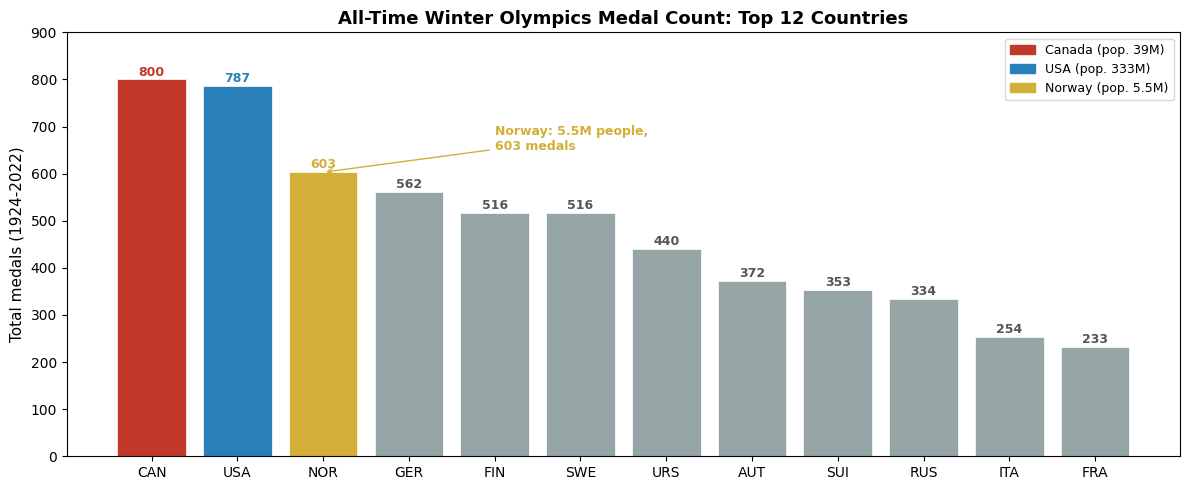

In [5]:
top15_raw = medal_df.groupby('noc').size().sort_values(ascending=False).head(12)

highlight = {'NOR': '#d4af37', 'CAN': '#c0392b', 'USA': '#2980b9'}
colors_raw = [highlight.get(n, '#95a5a6') for n in top15_raw.index]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(top15_raw.index, top15_raw.values, color=colors_raw, edgecolor='white', linewidth=0.5)

for bar, noc, val in zip(bars, top15_raw.index, top15_raw.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            str(val), ha='center', fontsize=9, fontweight='bold',
            color=highlight.get(noc, '#555'))

ax.annotate('Norway: 5.5M people,\n603 medals', xy=(2, 603),
            xytext=(4, 650), fontsize=9, color='#d4af37', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#d4af37'))

legend_handles = [
    mpatches.Patch(color='#c0392b', label='Canada (pop. 39M)'),
    mpatches.Patch(color='#2980b9', label='USA (pop. 333M)'),
    mpatches.Patch(color='#d4af37', label='Norway (pop. 5.5M)'),
]
ax.legend(handles=legend_handles, fontsize=9)
ax.set_ylabel('Total medals (1924-2022)', fontsize=11)
ax.set_title('All-Time Winter Olympics Medal Count: Top 12 Countries', fontsize=13, fontweight='bold')
ax.set_ylim(0, 900)
plt.tight_layout()
plt.show()


## Per Capita: Norway Is Not Just Better. It's on Another Planet.

When you divide total medals by population, Norway scores 110.5 medals per million people. Finland is second at 92.9. The United States, despite its raw total of 787 medals, scores just 2.4 per million.

To put that in perspective: Norway has won roughly **46 times more medals per person** than the United States. That is not a competitive gap -- that is a different relationship with winter sport entirely.

The pattern is clear: the top per-capita countries are all small, cold, northern European nations where skiing and skating are not sports -- they are transportation, culture, and childhood. Norway, Finland, Sweden, and Austria dominate this list not because they have better funding, but because winter sport is embedded in their national identity in a way it simply is not elsewhere.

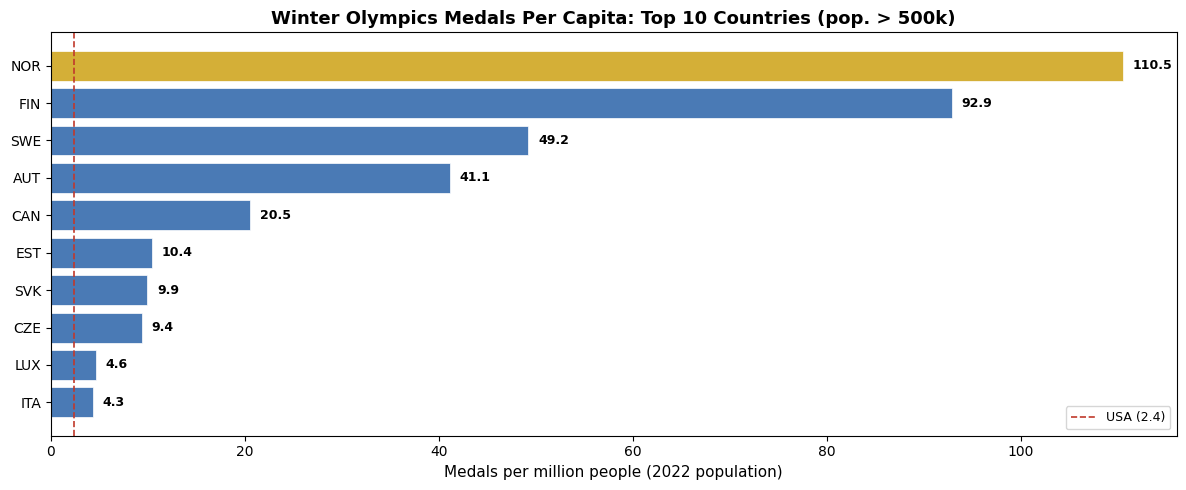

In [6]:
pops_2022 = pops[['Country Name', 'Country Code', '2022']].copy()
pops_2022.columns = ['country', 'code', 'pop2022']

total_medals = medal_df.groupby('noc').size().reset_index(name='total_medals')
merged = total_medals.merge(pops_2022, left_on='noc', right_on='code', how='left')
merged['medals_per_million'] = merged['total_medals'] / (merged['pop2022'] / 1e6)
merged = merged.dropna(subset=['pop2022'])
merged = merged[merged['pop2022'] > 500000]
top_pc = merged.sort_values('medals_per_million', ascending=False).head(10)

colors_pc = ['#d4af37' if n == 'NOR' else '#4a7ab5' for n in top_pc['noc']]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_pc['noc'][::-1], top_pc['medals_per_million'][::-1],
               color=colors_pc[::-1], edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top_pc['medals_per_million'][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9, fontweight='bold')

ax.axvline(merged[merged['noc']=='USA']['medals_per_million'].values[0],
           color='#c0392b', linestyle='--', linewidth=1.2, label='USA (2.4)')

ax.set_xlabel('Medals per million people (2022 population)', fontsize=11)
ax.set_title('Winter Olympics Medals Per Capita: Top 10 Countries (pop. > 500k)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## What Norway Actually Wins: A Master Class in Cross-Country

Norway's dominance is not spread evenly. It is highly concentrated in a small number of disciplines -- most of which involve skiing across long distances in freezing temperatures.

Cross-Country Skiing alone accounts for 227 of Norway's 603 medals -- more than a third of the entire haul. Add Biathlon, Nordic Combined, and Ski Jumping and you account for over 400 medals. Norway essentially built its Olympic dynasty on disciplines that require enduring cold and skiing uphill for extended periods.

The United States, by contrast, dominates in Ice Hockey, Speed Skating, and the freestyle and board sports that were added to the program after 1990. Different climates produce different champions.

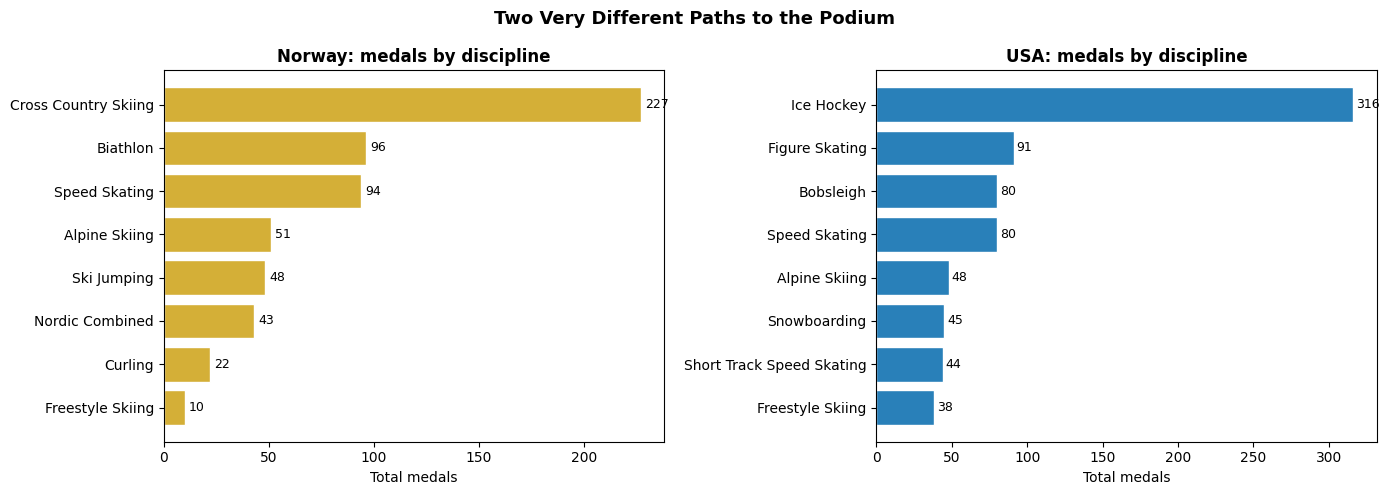

In [7]:
nor_disc = medal_df[medal_df['noc']=='NOR'].groupby('discipline').size().sort_values(ascending=False).head(8)
usa_disc = medal_df[medal_df['noc']=='USA'].groupby('discipline').size().sort_values(ascending=False).head(8)

def clean_disc(name):
    return name.split('(')[0].strip()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nor_labels = [clean_disc(d) for d in nor_disc.index]
usa_labels = [clean_disc(d) for d in usa_disc.index]

axes[0].barh(nor_labels[::-1], nor_disc.values[::-1], color='#d4af37', edgecolor='white')
axes[0].set_title('Norway: medals by discipline', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total medals', fontsize=10)
for i, v in enumerate(nor_disc.values[::-1]):
    axes[0].text(v + 2, i, str(v), va='center', fontsize=9)

axes[1].barh(usa_labels[::-1], usa_disc.values[::-1], color='#2980b9', edgecolor='white')
axes[1].set_title('USA: medals by discipline', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total medals', fontsize=10)
for i, v in enumerate(usa_disc.values[::-1]):
    axes[1].text(v + 2, i, str(v), va='center', fontsize=9)

fig.suptitle('Two Very Different Paths to the Podium', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## The Twist: The Games Have Changed, and the Map Is Spreading

Here is something the overall totals hide. The Winter Olympics in 1924 awarded 109 medals across 8 disciplines. By 2022, that number was 642 across 15 disciplines -- nearly six times as many medals per Games.

More events means more chances for smaller nations to win. And the newer disciplines -- Snowboarding, Freestyle Skiing, Short Track Speed Skating -- draw from a completely different athlete pool than the traditional Nordic events that built Norway's dynasty.

Ten countries won their first-ever Winter Olympics medal after 2018. Some, like Georgia and Colombia, had never appeared on a winter medals table before. The world of winter sport is genuinely expanding -- just slowly.

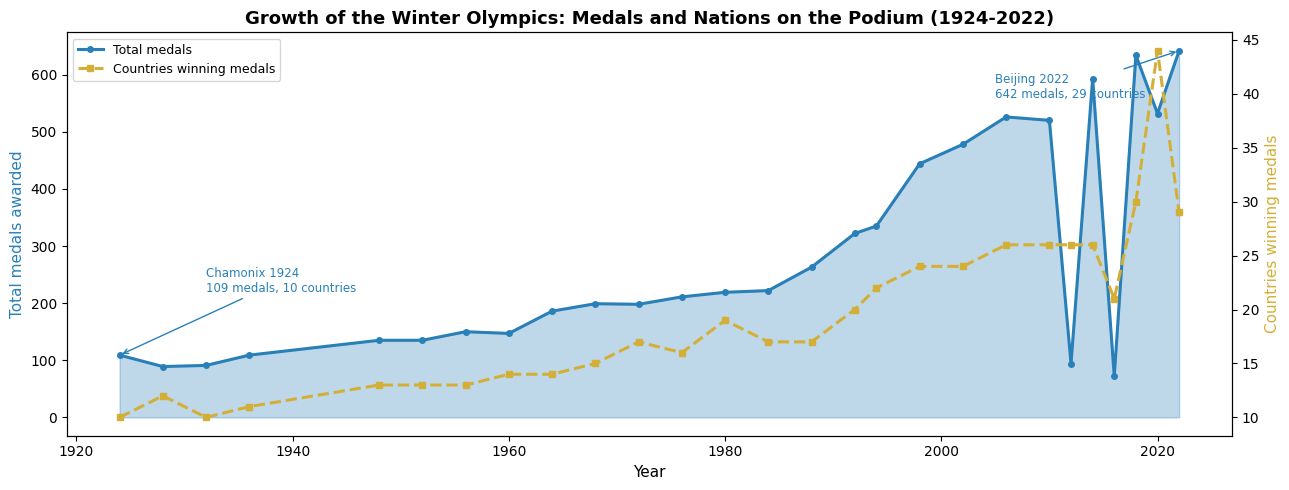

In [8]:
medals_by_year = medal_df.groupby('year').size()
countries_by_year = medal_df.groupby('year')['noc'].nunique()
years = medals_by_year.index

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.fill_between(years, medals_by_year.values, alpha=0.3, color='#2980b9')
ax1.plot(years, medals_by_year.values, color='#2980b9', linewidth=2.2, marker='o', markersize=4, label='Total medals')
ax2.plot(years, countries_by_year.values, color='#d4af37', linewidth=2.2, marker='s', markersize=4, linestyle='--', label='Countries winning medals')

ax1.annotate('Chamonix 1924\n109 medals, 10 countries',
             xy=(1924, 109), xytext=(1932, 220),
             fontsize=8.5, color='#2980b9',
             arrowprops=dict(arrowstyle='->', color='#2980b9'))
ax1.annotate('Beijing 2022\n642 medals, 29 countries',
             xy=(2022, 642), xytext=(2005, 560),
             fontsize=8.5, color='#2980b9',
             arrowprops=dict(arrowstyle='->', color='#2980b9'))

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Total medals awarded', fontsize=11, color='#2980b9')
ax2.set_ylabel('Countries winning medals', fontsize=11, color='#d4af37')
ax1.set_title('Growth of the Winter Olympics: Medals and Nations on the Podium (1924-2022)',
              fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
plt.tight_layout()
plt.show()


## The Athletes: Young, Old, and Extraordinary

The data in the athlete bios adds one more layer. The average age at the time of winning a Winter Olympics medal is 26. But the range is extraordinary.

The youngest gold medalist in this dataset is Kim Yun-Mi of South Korea, who won in Short Track Speed Skating at the 1994 Lillehammer Games at just 14 years old. At the other extreme, Robin Welsh of Great Britain won a Curling gold at the 1924 Games at age 55 -- a reminder that the original Winter Olympics included disciplines that looked very different from today's high-speed events.

And the most decorated winter Olympian of all time? Marit Bjørgen of Norway, with 15 medals across five Games. Of course it is a Norwegian.

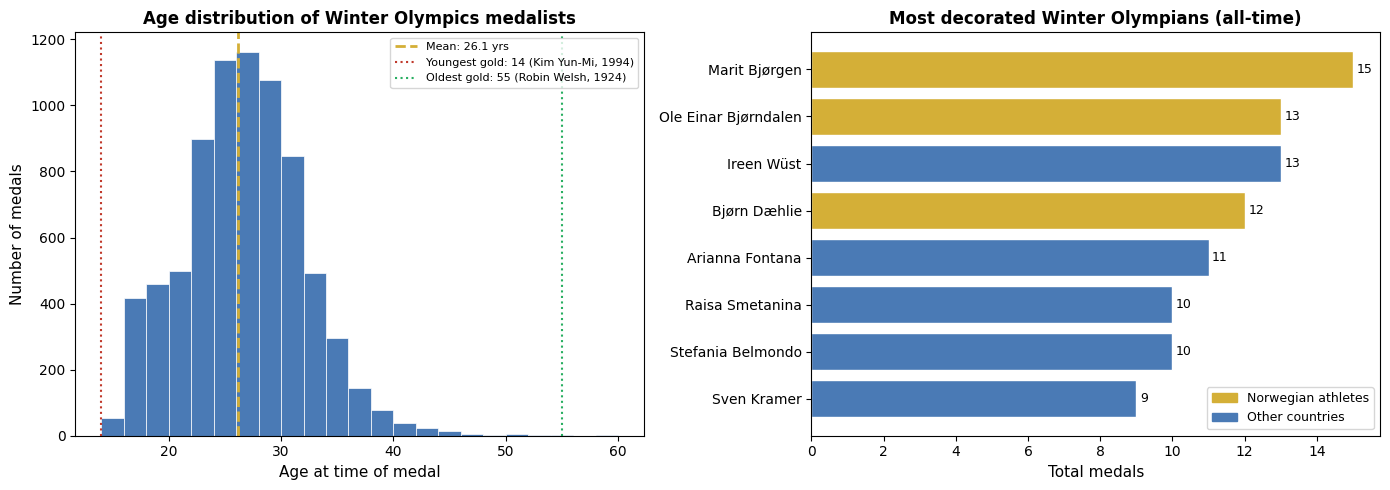

In [9]:
bios['born_date'] = pd.to_datetime(bios['born_date'], errors='coerce')
medal_bios = medal_df.merge(bios[['athlete_id', 'born_date']], on='athlete_id', how='left')
medal_bios['approx_age'] = medal_bios['year'] - medal_bios['born_date'].dt.year
medal_bios_clean = medal_bios[(medal_bios['approx_age'] >= 14) & (medal_bios['approx_age'] <= 60)]

athlete_medals = medal_df.groupby(['athlete_id', 'as']).size().reset_index(name='total')
top_athletes = athlete_medals.sort_values('total', ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(medal_bios_clean['approx_age'], bins=range(14, 61, 2),
             color='#4a7ab5', edgecolor='white', linewidth=0.5)
axes[0].axvline(medal_bios_clean['approx_age'].mean(), color='#d4af37',
                linestyle='--', linewidth=2, label=f'Mean: {medal_bios_clean["approx_age"].mean():.1f} yrs')
axes[0].axvline(14, color='#c0392b', linestyle=':', linewidth=1.5, label='Youngest gold: 14 (Kim Yun-Mi, 1994)')
axes[0].axvline(55, color='#27ae60', linestyle=':', linewidth=1.5, label='Oldest gold: 55 (Robin Welsh, 1924)')
axes[0].set_xlabel('Age at time of medal', fontsize=11)
axes[0].set_ylabel('Number of medals', fontsize=11)
axes[0].set_title('Age distribution of Winter Olympics medalists', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8)

nor_athletes = top_athletes.head(8)
bar_colors = ['#d4af37' if 'Bj' in name or 'Dæhlie' in name or 'Kalla' in name or 'Bø' in name
              else '#4a7ab5' for name in nor_athletes['as']]
axes[1].barh(nor_athletes['as'][::-1], nor_athletes['total'][::-1],
             color=bar_colors[::-1], edgecolor='white')
axes[1].set_xlabel('Total medals', fontsize=11)
axes[1].set_title('Most decorated Winter Olympians (all-time)', fontsize=12, fontweight='bold')
for i, v in enumerate(nor_athletes['total'][::-1]):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=9)
axes[1].legend(handles=[
    mpatches.Patch(color='#d4af37', label='Norwegian athletes'),
    mpatches.Patch(color='#4a7ab5', label='Other countries')
], fontsize=9)

plt.tight_layout()
plt.show()


## Conclusion

One hundred years of Winter Olympics data tells a story that cuts against the idea that size and resources determine success.

Canada and the United States top the raw medal table, but they are large countries with enormous athletic budgets. The per-capita leaders -- Norway, Finland, Sweden, Austria -- are small, cold nations where winter sport is not a funded program, it is a way of life.

Norway's 110.5 medals per million people is not the product of a superior sports system. It is the product of a country where children grow up skiing to school and cross-country trails are national infrastructure. You cannot manufacture that with money.

The games are expanding -- 2022 awarded nearly six times as many medals as 1924, and more countries than ever are reaching the podium. But the small, cold countries at the top of the per-capita table have not loosened their grip. Until the rest of the world starts skiing to school, they probably will not.